# Notebook 01 — Exploratory Data Analysis (EDA)

**Project:** Blood Donation Prediction System  
**Authors:** Mihret Alemayehu, Abebech Nega  
**Institution:** Debre Berhan University  
**Instructor:** Petros Abebe  

---

## Objective
This notebook is **fully self-contained** — it loads data directly from `../data/raw/`
and saves every chart as a high-quality PNG to `../reports/figures/`.

| Section | What you will see |
|---------|-------------------|
| 1 | Load raw dataset |
| 2 | Descriptive statistics |
| 3 | Missing value analysis |
| 4 | Target distribution (bar + donut) |
| 5 | Pearson correlation heatmap |
| 6 | Feature distributions (histogram + KDE) |
| 7 | Box plots by target class |

> **Tip:** Use *Kernel → Restart & Run All* to regenerate every figure from scratch.


In [33]:
# ─── Cell 1: Imports, magic, paths, output folder ───────────────────────────
%matplotlib inline

import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Relative paths (work in VS Code when notebook is in notebooks/) ───────────
NB_DIR      = os.path.dirname(os.path.abspath('__file__'))  # notebooks/
ROOT        = os.path.abspath(os.path.join(NB_DIR, '..'))
RAW_CSV     = os.path.join(ROOT, 'data', 'raw', 'blood_donation.csv')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(FIGURES_DIR, exist_ok=True)   # create folder if it doesn't exist

TARGET = 'Target'

# ── Beautiful chart style ────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 14,
    'axes.labelsize'   : 11,
    'figure.facecolor' : '#FAFBFC',
    'axes.facecolor'   : '#FAFBFC',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
})
sns.set_theme(style='whitegrid', font_scale=1.1)

COLORS = ['#E74C3C', '#3498DB', '#9B59B6', '#2ECC71', '#F39C12', '#1ABC9C']
RED, BLUE, PURPLE, GREEN, AMBER = COLORS[:5]

def save_fig(fig, filename):
    """Save figure to reports/figures/ at high DPI, then display inline."""
    path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(path, dpi=160, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'  Saved → reports/figures/{filename}')

print(f'Figures folder : {FIGURES_DIR}')
print(f'Raw data file  : {RAW_CSV}')
print('All libraries loaded. Ready to run.')


Figures folder : c:\Users\HP\Downloads\Blood_Donation_COMPLETE_FINAL (1)\Blood-Donation-Prediction-System\reports\figures
Raw data file  : c:\Users\HP\Downloads\Blood_Donation_COMPLETE_FINAL (1)\Blood-Donation-Prediction-System\data\raw\blood_donation.csv
All libraries loaded. Ready to run.


---
## Section 1 — Load the Raw Dataset

We load `blood_donation.csv` directly using pandas. No helper classes needed.


In [34]:
# ─── Cell 2: Load raw CSV ────────────────────────────────────────────────────
df_raw = pd.read_csv(RAW_CSV)

print('Shape          :', df_raw.shape)
print('Rows           :', len(df_raw))
print('Columns        :', df_raw.shape[1])
print('Dtypes summary :')
print(df_raw.dtypes.value_counts().to_string())
print()
print('First 5 rows:')
df_raw.head()


Shape          : (5950, 8)
Rows           : 5950
Columns        : 8
Dtypes summary :
float64    3
int64      3
str        2

First 5 rows:


,Donor_Age,Blood_Type,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),Donation_Location,Target
0,48.0,B+,26.0,37.0,14015,84,Hospital,0
1,64.0,A+,12.0,6.0,11302,85,Mobile_Bus,1
2,46.0,A-,23.0,16.0,3674,39,Hospital,1
3,29.0,AB-,28.0,47.0,651,62,Mobile_Bus,0
4,28.0,O+,28.0,51.0,10540,68,Clinic,0


---
## Section 2 — Descriptive Statistics

`.describe()` gives count, mean, std, min, quartiles, and max for every numeric column.


In [35]:
# ─── Cell 3: Descriptive statistics ─────────────────────────────────────────
desc = df_raw.describe().T.round(3)
desc


,count,mean,std,min,25%,50%,75%,max
Donor_Age,5655.0,41.513,14.934,18.0,29.00,41.0,53.00,150.0
Recency (months),5652.0,15.019,8.396,1.0,8.00,15.0,22.00,29.0
Frequency (times),5655.0,30.309,17.146,1.0,15.00,31.0,45.00,59.0
Monetary (c.c. blood),5950.0,11257.530,60389.895,250.0,3876.75,7560.5,11365.75,999999.0
Time (months),5950.0,50.105,28.395,1.0,26.00,50.0,74.00,99.0
Target,5950.0,0.492,0.500,0.0,0.00,0.0,1.00,1.0


In [36]:
# ─── Cell 4: Column data types and null counts ───────────────────────────────
info_df = pd.DataFrame({
    'dtype'        : df_raw.dtypes,
    'non_null'     : df_raw.notnull().sum(),
    'null_count'   : df_raw.isnull().sum(),
    'null_pct'     : (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'unique_values': df_raw.nunique(),
})
info_df


,dtype,non_null,null_count,null_pct,unique_values
Donor_Age,float64,5655,295,4.96,48
Blood_Type,str,5950,0,0.00,8
Recency (months),float64,5652,298,5.01,29
Frequency (times),float64,5655,295,4.96,59
Monetary (c.c. blood),int64,5950,0,0.00,4776
Time (months),int64,5950,0,0.00,99
Donation_Location,str,5950,0,0.00,3
Target,int64,5950,0,0.00,2


---
## Section 3 — Missing Value Analysis

Understanding which columns have missing data guides our imputation strategy.
We use **KNN Imputation (k=5)** to fill missing values (see Notebook 02).


  Saved → reports/figures/missing_values.png


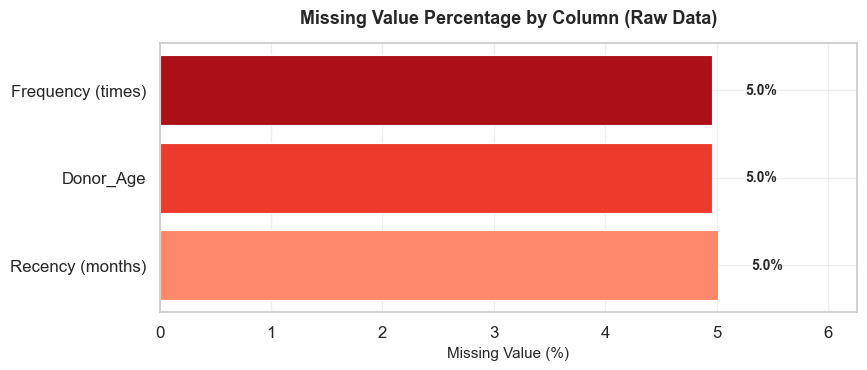

In [37]:
# ─── Cell 5: Missing value bar chart ────────────────────────────────────────
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if missing_pct.empty:
    print('No missing values found in the raw dataset.')
else:
    bar_colors = plt.cm.Reds(np.linspace(0.4, 0.85, len(missing_pct)))

    fig, ax = plt.subplots(figsize=(9, max(3.5, len(missing_pct) * 0.6)))
    bars = ax.barh(missing_pct.index, missing_pct.values,
                   color=bar_colors, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, missing_pct.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left',
                fontsize=10, fontweight='bold')
    ax.set_xlabel('Missing Value (%)', fontsize=11)
    ax.set_title('Missing Value Percentage by Column (Raw Data)',
                 fontsize=13, fontweight='bold')
    ax.set_xlim(0, missing_pct.max() * 1.25)

    save_fig(fig, 'missing_values.png')
    plt.show()
    plt.close(fig)


---
## Section 4 — Target Variable Distribution

The `Target` column is binary:
- **0** = Won't donate blood in the next campaign
- **1** = Will donate blood in the next campaign

We check for class imbalance using a bar chart and a donut chart.


Class distribution:
  0 (Won't Donate): 3,021  (50.8%)
  1 (Will Donate ): 2,929  (49.2%)
  Saved → reports/figures/target_distribution.png


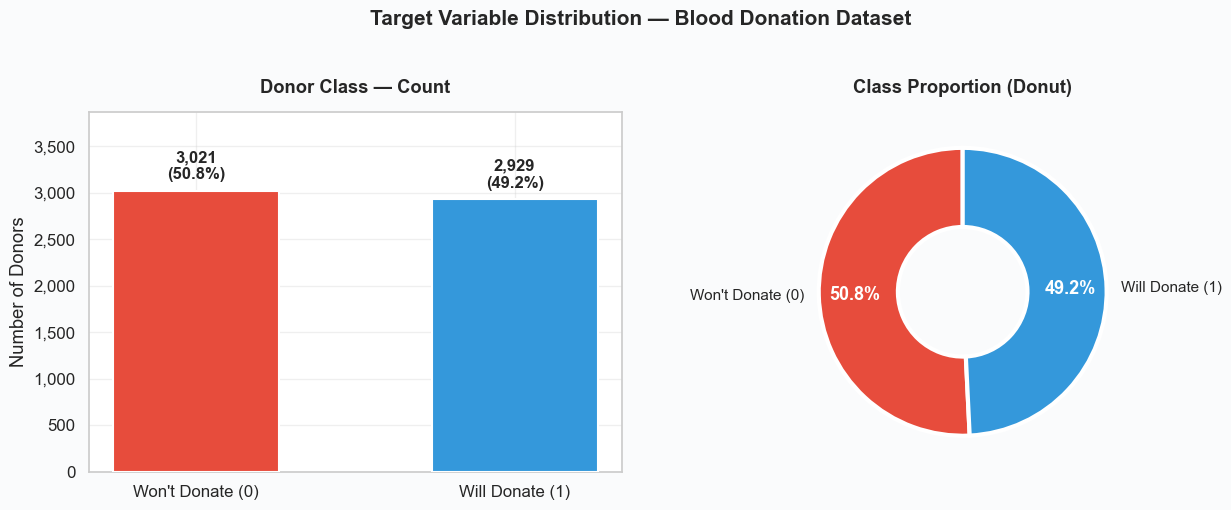

In [38]:
# ─── Cell 6: Target distribution — bar + donut ───────────────────────────────
counts = df_raw[TARGET].value_counts().sort_index()
total  = counts.sum()

print('Class distribution:')
for idx, cnt in counts.items():
    label = 'Will Donate' if idx == 1 else "Won't Donate"
    print(f'  {idx} ({label:12s}): {cnt:,}  ({cnt/total*100:.1f}%)')

fig, (ax_bar, ax_pie) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FAFBFC')

# -- Bar chart --
bar_lbls = ["Won't Donate (0)", 'Will Donate (1)']
bars = ax_bar.bar(bar_lbls, counts.values, color=[RED, BLUE],
                  edgecolor='white', width=0.52, linewidth=1.5, zorder=3)
for bar, cnt in zip(bars, counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.015,
                f'{cnt:,}\n({cnt/total*100:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
ax_bar.set_title('Donor Class — Count', fontweight='bold')
ax_bar.set_ylabel('Number of Donors')
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax_bar.set_ylim(0, counts.max() * 1.28)

# -- Donut chart --
wedges, texts, autotexts = ax_pie.pie(
    counts.values, labels=bar_lbls, colors=[RED, BLUE],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 3},
    pctdistance=0.75, textprops={'fontsize': 11})
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white'); at.set_fontsize(13)
ax_pie.set_title('Class Proportion (Donut)', fontweight='bold')

fig.suptitle('Target Variable Distribution — Blood Donation Dataset',
             fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()

save_fig(fig, 'target_distribution.png')
plt.show()
plt.close(fig)


---
## Section 5 — Pearson Correlation Heatmap

Correlations reveal how strongly each pair of numeric features are linearly related.
Values close to +1 or −1 indicate strong relationships; near 0 means weak/no linear relationship.


  Saved → reports/figures/correlation_heatmap.png


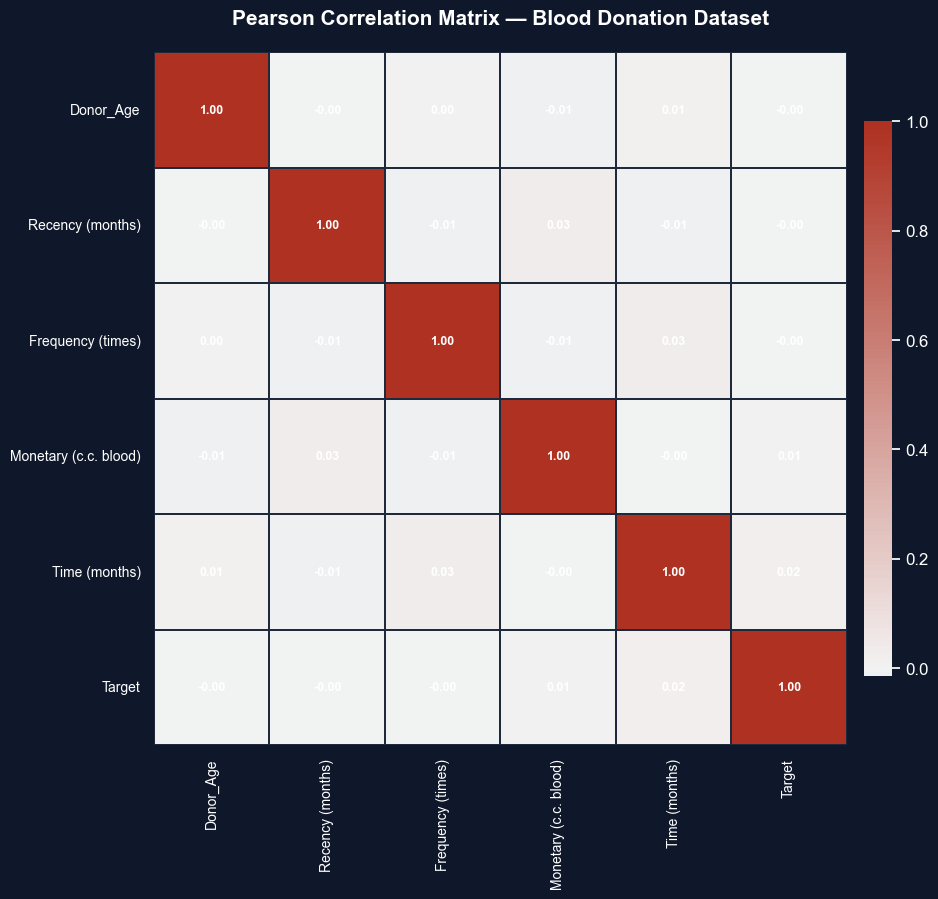

In [39]:
# ─── Cell 7: Correlation heatmap (dark theme) ────────────────────────────────
numeric_df = df_raw.select_dtypes(include=[np.number])
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#0F172A')
ax.set_facecolor('#0F172A')

cmap = sns.diverging_palette(230, 15, s=85, l=40, as_cmap=True)
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap=cmap, center=0,
    linewidths=1.2, linecolor='#1E293B', square=True, ax=ax,
    annot_kws={'size': 9, 'weight': 'bold', 'color': 'white'},
    cbar_kws={'shrink': 0.8, 'pad': 0.02},
)
ax.set_title('Pearson Correlation Matrix — Blood Donation Dataset',
             fontsize=15, fontweight='bold', color='white', pad=20)
ax.tick_params(colors='white', labelsize=10)
for sp in ax.spines.values():
    sp.set_visible(False)
ax.collections[0].colorbar.ax.tick_params(colors='white')

save_fig(fig, 'correlation_heatmap.png')
plt.show()
plt.close(fig)


In [40]:
# ─── Cell 8: Print top correlations with Target ───────────────────────────────
if TARGET in corr.columns:
    target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
    print('Correlation with Target (sorted by |r|):')
    print(target_corr.to_string())


Correlation with Target (sorted by |r|):
Time (months)            0.021239
Monetary (c.c. blood)    0.005940
Frequency (times)       -0.004627
Recency (months)        -0.003985
Donor_Age               -0.003757


---
## Section 6 — Feature Distributions

Each histogram shows how values are spread across the numeric columns.
The red KDE (kernel density estimate) line shows the smoothed shape of the distribution.


  Saved → reports/figures/feature_distributions.png


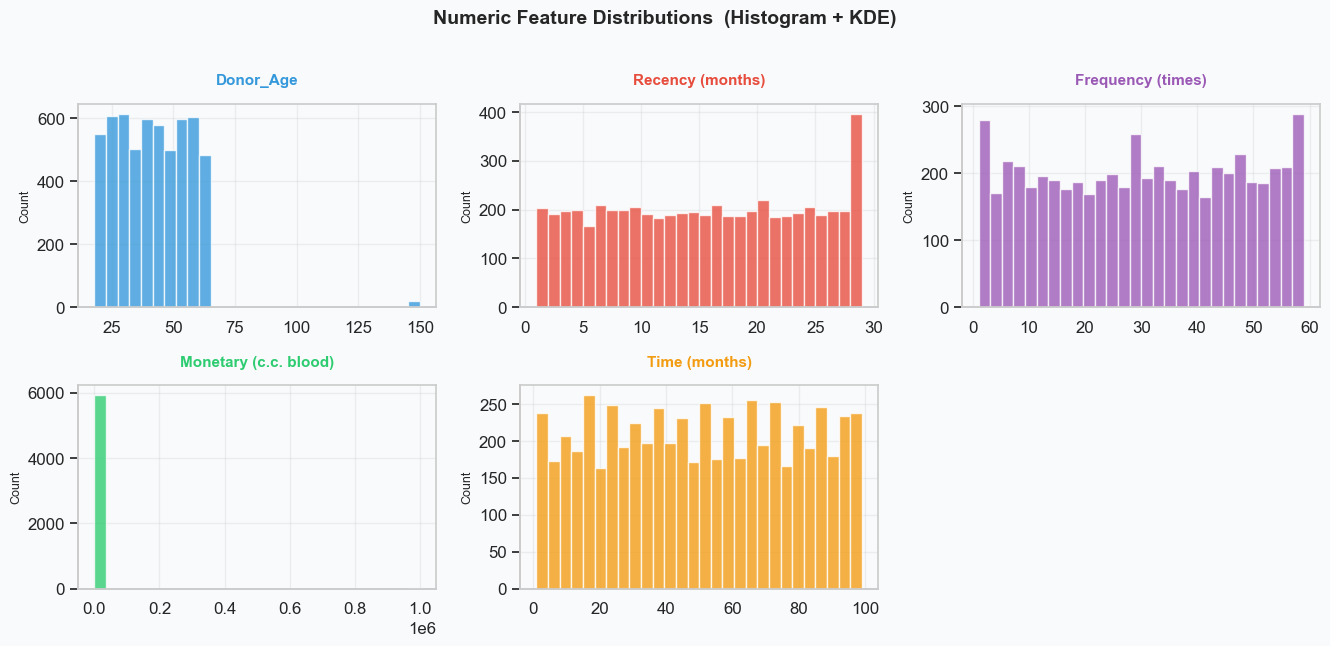

In [41]:
# ─── Cell 9: Feature distribution grid (histogram + KDE) ────────────────────
feat_cols   = [c for c in numeric_df.columns if c != TARGET]
color_cycle = [BLUE, RED, PURPLE, GREEN, AMBER, '#1ABC9C', '#E67E22', '#2980B9', '#8E44AD']
ncols = 3
nrows = (len(feat_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.2))
fig.patch.set_facecolor('#F8FAFC')
axes = np.array(axes).ravel()

for i, col in enumerate(feat_cols):
    c    = color_cycle[i % len(color_cycle)]
    data = df_raw[col].dropna()

    axes[i].hist(data, bins=28, color=c, edgecolor='white', alpha=0.78, zorder=3)
    ax2 = axes[i].twinx()
    try:
        data.plot.kde(ax=ax2, color=c, linewidth=2.2)
    except Exception:
        pass
    ax2.set_ylabel(''); ax2.set_yticks([])
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    axes[i].set_title(col, fontsize=11, fontweight='bold', color=c)
    axes[i].set_ylabel('Count', fontsize=9)
    axes[i].set_facecolor('#F8FAFC')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Feature Distributions  (Histogram + KDE)',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()

save_fig(fig, 'feature_distributions.png')
plt.show()
plt.close(fig)


---
## Section 7 — Box Plots by Target Class

Box plots split by `Target` reveal whether each feature has different distributions
for donors vs. non-donors — a strong signal of predictive power.

- **Red** = Won't Donate (0)
- **Blue** = Will Donate (1)


  Saved → reports/figures/boxplots_by_target.png


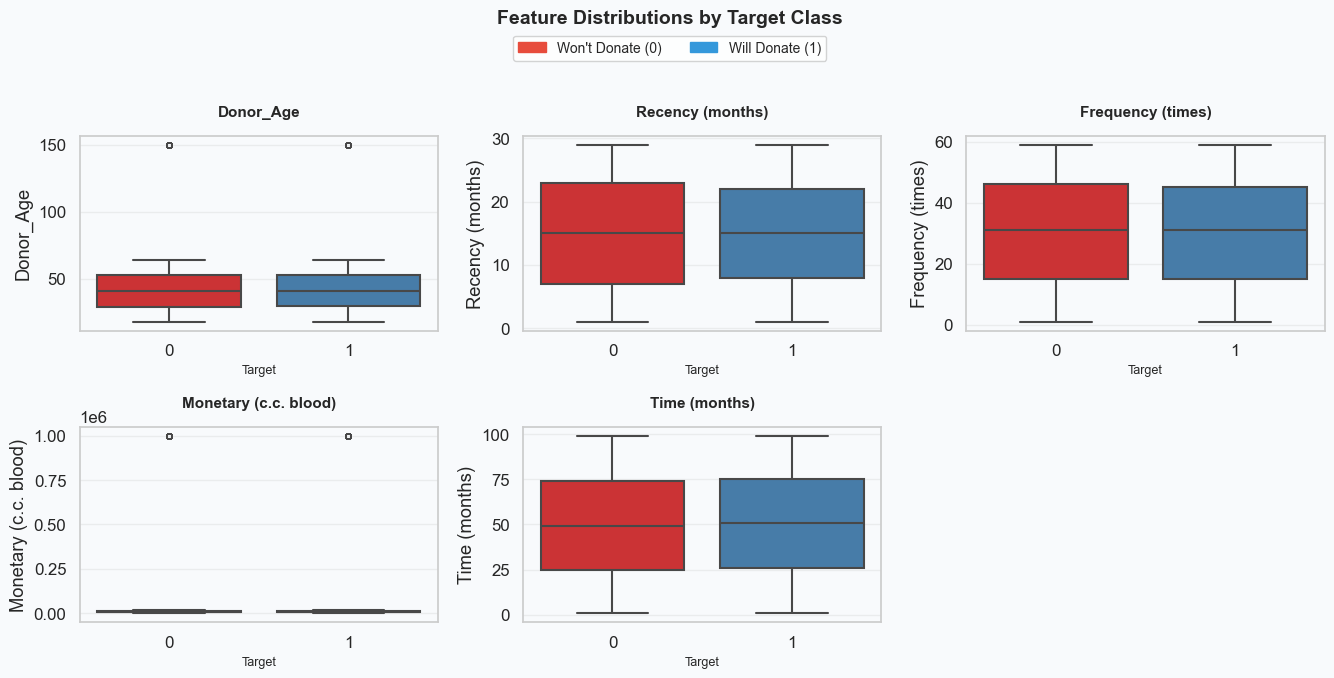

In [42]:
# ─── Cell 10: Box plots by target class ─────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 3.2))
fig.patch.set_facecolor('#F8FAFC')
axes = np.array(axes).ravel()

for i, col in enumerate(feat_cols):
    sns.boxplot(
        x=TARGET, y=col, data=df_raw,
        hue=TARGET,            # Adding hue helps Seaborn map colors correctly
        palette="Set1",        # Using a standard palette avoids the dictionary key error
        ax=axes[i], linewidth=1.5, fliersize=4,
        legend=False           # We will use your custom legend instead
    )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Target', fontsize=9)
    axes[i].set_facecolor('#F8FAFC')

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Custom legend to match your project's theme
legend_patches = [
    mpatches.Patch(color=RED,  label="Won't Donate (0)"),
    mpatches.Patch(color=BLUE, label='Will Donate (1)'),
]
fig.legend(handles=legend_patches, loc='upper center', ncol=2,
           fontsize=10, framealpha=0.85, bbox_to_anchor=(0.5, 1.03))

fig.suptitle('Feature Distributions by Target Class',
             fontsize=14, fontweight='bold', y=1.06)
fig.tight_layout()

# Save and display the visualization
save_fig(fig, 'boxplots_by_target.png')
plt.show()
plt.close(fig)

---
## Section 8 — Pairwise Scatter Plot

A pairplot shows all numeric feature combinations colored by target class.
This helps spot natural clusters between donors and non-donors.


  Saved → reports/figures/pairplot.png


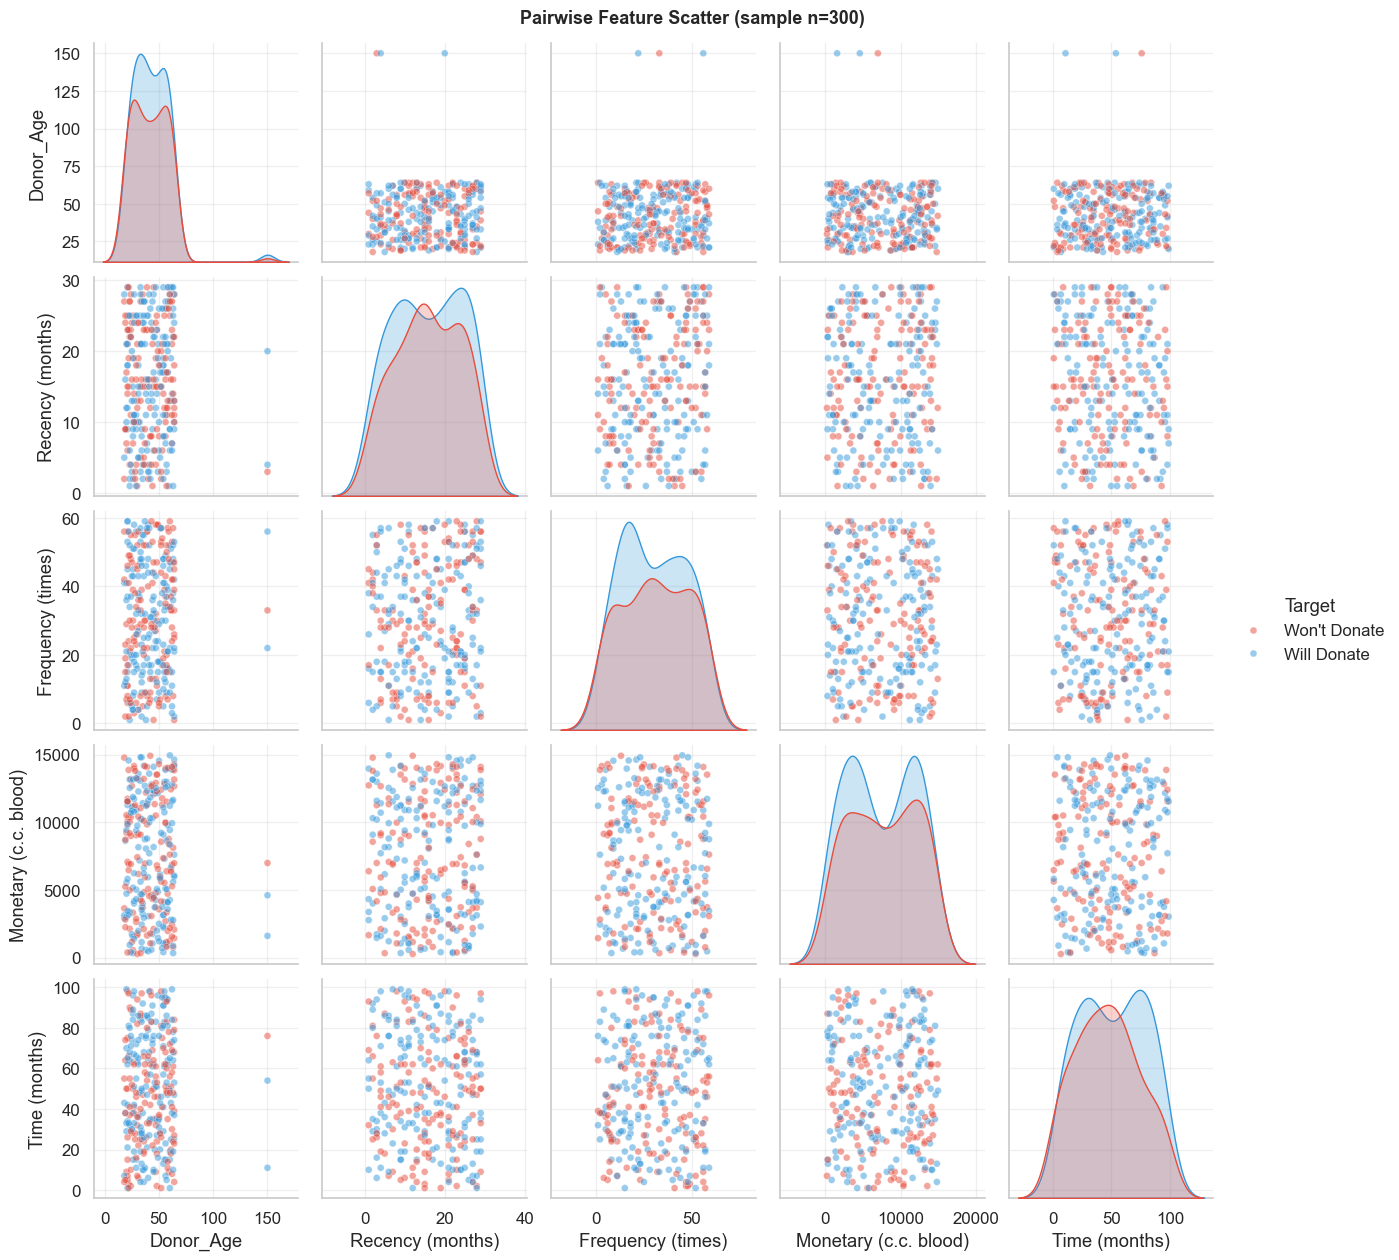

In [43]:
# ─── Cell 11: Pairplot (scatter matrix) ──────────────────────────────────────
# Use a sample to keep it fast (pairplots are slow with many rows)
sample_df = df_raw.dropna().sample(min(300, len(df_raw)), random_state=42)
sample_df[TARGET] = sample_df[TARGET].astype(str).map({'0': "Won't Donate", '1': 'Will Donate'})

pair_cols = [c for c in feat_cols if c in sample_df.columns][:5]  # max 5 features

pairplot_fig = sns.pairplot(
    sample_df[pair_cols + [TARGET]],
    hue=TARGET,
    palette={"Won't Donate": RED, 'Will Donate': BLUE},
    plot_kws={'alpha': 0.5, 's': 25},
    diag_kind='kde',
)
pairplot_fig.fig.suptitle('Pairwise Feature Scatter (sample n=300)',
                          fontsize=13, y=1.01, fontweight='bold')

save_fig(pairplot_fig.fig, 'pairplot.png')
plt.show()
plt.close('all')


---
## Summary

All EDA charts have been:
1. ✅ **Displayed inline** using `%matplotlib inline` + `plt.show()`
2. ✅ **Saved as PNG** to `reports/figures/` using `fig.savefig()`

### Figures saved:
| File | Description |
|------|-------------|
| `missing_values.png` | Missing value % per column |
| `target_distribution.png` | Class balance bar + donut |
| `correlation_heatmap.png` | Pearson correlation matrix |
| `feature_distributions.png` | Histogram + KDE grid |
| `boxplots_by_target.png` | Box plots by donor class |
| `pairplot.png` | Pairwise scatter matrix |

### Next Step
Open **`02_preprocessing.ipynb`** to clean, impute, and engineer features.
